Code run start time: 20/08/2026 11:33:33

Loading consolidated raw dataset from:
/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/proc-data/cpi-mospi-b2012-data-consolidated.xlsx...

--> Mapped Columns:
    - Headline : 'General-Overall'
    - Food     : 'Consumer Food Price-Overall'
    - Fuel     : 'Fuel and Light-Overall'
--> Saved processed Excel data to: /Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/proc-data/cpi-mospi-processed-inflation.xlsx
PNG Export warning (ensure kaleido is installed): Type is not JSON serializable: Timestamp
--> Saved interactive HTML to 'india-cpi-inflation.html'


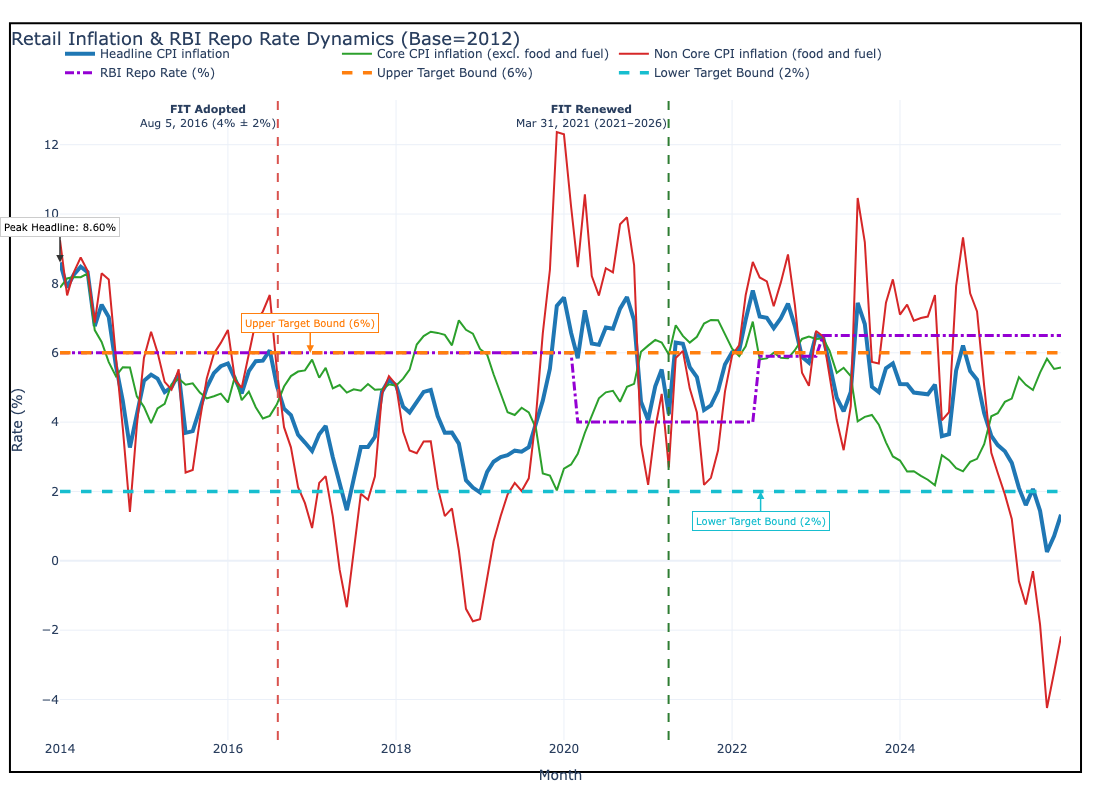


Code run end time: 20/08/2026 11:33:47
Total elapsed time (seconds): 13.81


In [20]:
################################################################################
## CONSOLIDATED CPI DATA PROCESSING & INFLATION VISUALIZATION PIPELINE
################################################################################

import os
import time
from datetime import datetime
import pandas as pd
import requests
import plotly.graph_objects as go

# --------------------------------------------
# TIMER & START TIME
# --------------------------------------------
code_start_time = datetime.now()
timer_start = time.time()
print("Code run start time:", code_start_time.strftime("%d/%m/%Y %H:%M:%S"))

# --------------------------------------------
# ========= CONFIGURE PATHS & STUBS =========
# --------------------------------------------
proj_stub = r"/Users/kalyan/Library/CloudStorage/OneDrive-Personal/Kalyan/KK-Python/Kalyan-Jupyter-Notebooks/data/"
stub = r"cpi-mospi"
byear_stub = r"2012"  # Standard CPI Base Year

BASE_DIR = f"{proj_stub}"
RAW_DIR = os.path.join(BASE_DIR, f"raw-data/{stub}")
INTERIM_DIR = os.path.join(BASE_DIR, "interim-data")
PROCESSED_DIR = os.path.join(BASE_DIR, "proc-data")

os.makedirs(PROCESSED_DIR, exist_ok=True)

# File Paths
cpi_master_data_file = os.path.join(PROCESSED_DIR, f"{stub}-b{byear_stub}-data-consolidated.xlsx")
processed_output_excel = os.path.join(PROCESSED_DIR, f"{stub}-processed-inflation.xlsx")
output_html = "india-cpi-inflation.html"
output_png =  "india-cpi-inflation.png"

# --------------------------------------------
# HELPER: FETCH RBI REPO RATE
# --------------------------------------------
def fetch_rbi_repo_rate(date_series):
    """
    Attempts to fetch official RBI Repo Rate series via API.
    Provides a fallback trajectory aligned with historical RBI monetary decisions.
    """
    api_url = "https://api.dbie.rbi.org.in/v1/repo-rate"  # RBI DBIE Endpoint Stub
    try:
        response = requests.get(api_url, timeout=3)
        if response.status_code == 200:
            repo_json = response.json()
            df_repo = pd.DataFrame(repo_json)
            df_repo['date'] = pd.to_datetime(df_repo['date'])
            return df_repo
    except Exception:
        pass  # Fallback if API is offline

    # Fallback historical Policy Repo Rate mapping
    min_date = date_series.min()
    max_date = date_series.max()
    full_dates = pd.date_range(start=min_date, end=max_date, freq='MS')
    
    repo_df = pd.DataFrame({'date': full_dates})
    repo_df['repo_rate'] = 6.50
    repo_df.loc[repo_df['date'] < '2020-03-01', 'repo_rate'] = 6.00
    repo_df.loc[(repo_df['date'] >= '2020-03-01') & (repo_df['date'] < '2022-05-01'), 'repo_rate'] = 4.00
    repo_df.loc[(repo_df['date'] >= '2022-05-01') & (repo_df['date'] < '2023-02-01'), 'repo_rate'] = 5.90
    
    return repo_df

# --------------------------------------------
# STEP 1: LOAD CONSOLIDATED CPI DATA
# --------------------------------------------
print(f"\nLoading consolidated raw dataset from:\n{cpi_master_data_file}...")
raw_df = pd.read_excel(cpi_master_data_file, sheet_name="CPI-CONSOLIDATED-MASTER")

# Standardize column headers
raw_df.columns = raw_df.columns.str.strip().str.lower()

# --------------------------------------------
# STEP 2: FILTER COMBINED ALL-INDIA LEVEL DATA
# --------------------------------------------
filtered_df = raw_df.copy()

if 'sector' in filtered_df.columns:
    filtered_df = filtered_df[
        filtered_df['sector'].astype(str).str.contains('Combined|3', case=False, na=False)
    ].copy()

if 'state' in filtered_df.columns:
    all_india_mask = filtered_df['state'].astype(str).str.contains('All India|National', case=False, na=False)
    if all_india_mask.any():
        filtered_df = filtered_df[all_india_mask].copy()

# --------------------------------------------
# STEP 3: RESHAPE & PIVOT TIME SERIES
# --------------------------------------------
year_col = 'extracted_year' if 'extracted_year' in filtered_df.columns else 'year'
month_col = 'extracted_month' if 'extracted_month' in filtered_df.columns else 'month'

desc_col = 'subgroup' if 'subgroup' in filtered_df.columns else 'group'
val_col = 'index'

filtered_df[val_col] = pd.to_numeric(filtered_df[val_col], errors='coerce')

filtered_df['date'] = pd.to_datetime(
    filtered_df[year_col].astype(str) + '-' + filtered_df[month_col].astype(str).str.zfill(2) + '-01'
)

df_pivoted = filtered_df.pivot_table(
    index='date',
    columns=desc_col,
    values=val_col,
    aggfunc='mean'
).reset_index().sort_values('date')

df_pivoted['Month'] = df_pivoted['date'].dt.strftime('%b %Y')

cols = df_pivoted.columns.tolist()

headline_col = next((c for c in cols if 'general' in str(c).lower() or 'headline' in str(c).lower() or str(c).lower() == 'cpi'), None)
food_col = next((c for c in cols if 'food' in str(c).lower()), None)
fuel_col = next((c for c in cols if 'fuel' in str(c).lower()), None)

print(f"\n--> Mapped Columns:\n    - Headline : '{headline_col}'\n    - Food     : '{food_col}'\n    - Fuel     : '{fuel_col}'")

# --------------------------------------------
# STEP 4: CPI INDEX CALCULATIONS
# --------------------------------------------
w_food = 45.86
w_fuel = 6.84
w_noncore = w_food + w_fuel             # 52.70
w_core = 100.0 - w_noncore              # 47.30

# Indices
df_pivoted['Headline_CPI_Index'] = df_pivoted[headline_col]

df_pivoted['Non_Core_CPI_Index'] = (
    (df_pivoted[food_col] * w_food) + (df_pivoted[fuel_col] * w_fuel)
) / w_noncore

df_pivoted['Core_CPI_Index'] = (
    (df_pivoted[headline_col] * 100.0) - (df_pivoted[food_col] * w_food) - (df_pivoted[fuel_col] * w_fuel)
) / w_core

# --------------------------------------------
# STEP 5: YEAR-ON-YEAR (YoY) MONTHLY INFLATION
# --------------------------------------------
df_pivoted['Headline CPI inflation'] = df_pivoted['Headline_CPI_Index'].pct_change(12) * 100
df_pivoted['Core CPI inflation (excl. food and fuel)'] = df_pivoted['Core_CPI_Index'].pct_change(12) * 100
df_pivoted['Non Core CPI inflation (food and fuel)'] = df_pivoted['Non_Core_CPI_Index'].pct_change(12) * 100

df_analysis = df_pivoted.dropna(subset=['Headline CPI inflation']).copy()

# Date bounds strictly for the dataset
min_date = df_analysis['date'].min()
max_date = df_analysis['date'].max()

# Fetch Repo Rate & trim strictly to date range
df_repo = fetch_rbi_repo_rate(df_analysis['date'])
df_repo = df_repo[(df_repo['date'] >= min_date) & (df_repo['date'] <= max_date)].copy()

# Export to Excel
with pd.ExcelWriter(processed_output_excel, engine="openpyxl") as writer:
    df_analysis.to_excel(writer, sheet_name="CPI_Inflation_Processed", index=False)
print(f"--> Saved processed Excel data to: {processed_output_excel}")

# --------------------------------------------
# STEP 6: PLOTLY GRAPH VISUALIZATION & PNG EXPORT
# --------------------------------------------
fig1 = go.Figure()

# 1. Primary CPI Traces (Left Scale)
fig1.add_trace(go.Scatter(
    x=df_analysis['date'],
    y=df_analysis['Headline CPI inflation'],
    mode='lines',
    name='Headline CPI inflation',
    line=dict(color='#1f77b4', width=4)
))

fig1.add_trace(go.Scatter(
    x=df_analysis['date'],
    y=df_analysis['Core CPI inflation (excl. food and fuel)'],
    mode='lines',
    name='Core CPI inflation (excl. food and fuel)',
    line=dict(color='#2ca02c', width=2)
))

fig1.add_trace(go.Scatter(
    x=df_analysis['date'],
    y=df_analysis['Non Core CPI inflation (food and fuel)'],
    mode='lines',
    name='Non Core CPI inflation (food and fuel)',
    line=dict(color='#d62728', width=2)
))

# 2. RBI Repo Rate (Left Scale - Violet Dot-Dash)
fig1.add_trace(go.Scatter(
    x=df_repo['date'],
    y=df_repo['repo_rate'],
    mode='lines',
    name='RBI Repo Rate (%)',
    line=dict(color='darkviolet', width=3, dash='dashdot')
))

# 3. Target Bounds Traces (Left Scale - Capped to min_date and max_date)
fig1.add_trace(go.Scatter(
    x=[min_date, max_date],
    y=[6, 6],
    mode='lines',
    name='Upper Target Bound (6%)',
    line=dict(color='#ff7f0e', width=3.5, dash='dash')
))

fig1.add_trace(go.Scatter(
    x=[min_date, max_date],
    y=[2, 2],
    mode='lines',
    name='Lower Target Bound (2%)',
    line=dict(color='#17becf', width=3.5, dash='dash')
))

# --------------------------------------------
# CALLOUT ANNOTATIONS (STRICTLY WITHIN TIMELINE)
# --------------------------------------------
total_days = (max_date - min_date).days

# Positioning callouts at ~25% and ~70% along the timeline
callout_date_upper = min_date + pd.Timedelta(days=int(total_days * 0.25))
callout_date_lower = min_date + pd.Timedelta(days=int(total_days * 0.70))

# Callout 1: Upper Target Bound (6%)
fig1.add_annotation(
    x=callout_date_upper,
    y=6,
    text="Upper Target Bound (6%)",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="#ff7f0e",
    ax=0,
    ay=-30,
    font=dict(size=10, color="#ff7f0e"),
    bgcolor="white",
    bordercolor="#ff7f0e",
    borderwidth=1,
    borderpad=3
)

# Callout 2: Lower Target Bound (2%)
fig1.add_annotation(
    x=callout_date_lower,
    y=2,
    text="Lower Target Bound (2%)",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="#17becf",
    ax=0,
    ay=30,
    font=dict(size=10, color="#17becf"),
    bgcolor="white",
    bordercolor="#17becf",
    borderwidth=1,
    borderpad=3
)

# Callout 3: Peak Inflation Spike
peak_row = df_analysis.loc[df_analysis['Headline CPI inflation'].idxmax()]
fig1.add_annotation(
    x=peak_row['date'],
    y=peak_row['Headline CPI inflation'],
    text=f"Peak Headline: {peak_row['Headline CPI inflation']:.2f}%",
    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,
    arrowcolor="#333333",
    ax=0,
    ay=-35,
    font=dict(size=10, color="black"),
    bgcolor="white",
    bordercolor="#cccccc",
    borderwidth=1,
    borderpad=3
)

# --------------------------------------------
# LAYOUT & PROPORTIONAL DIMENSIONS
# --------------------------------------------
# 3.B Add a full canvas border shape
fig1.add_shape(type="rect",
    xref="paper", yref="paper",
    x0=-0.05, y0=-0.05, x1=1.02, y1=1.12, 
    line=dict(
        #color="RoyalBlue",
        color="black", #named colors from https://stackoverflow.com/a/72502441/8508004
        width=2,
    ),
    #fillcolor="LightSkyBlue",
)

fig1.update_layout(
    width=1100,
    height=800,
    title=dict(
        text='Retail Inflation & RBI Repo Rate Dynamics (Base=2012)',
        x=0.01,
        y=0.96,  font=dict(size=18),
    ),
    template='plotly_white',
    legend=dict(
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0.0,
        orientation="h"
    ),
    showlegend=True,
    xaxis=dict(
        title="Month",
        range=[min_date, max_date],  # Strictly clip timeline display
        autorange=False
    ),
    yaxis=dict(
        title="Rate (%)",
        side="left"
    ),
    margin=dict(l=60, r=40, t=100, b=60)
)


# 1. FIT Adoption Line (Aug 5, 2016)
fig1.add_vline(
    x="2016-08-05",
    line_width=2,
    line_dash="dash",
    line_color="#D9534F",
    annotation_text="<b>FIT Adopted</b><br>Aug 5, 2016 (4% ± 2%)",
    annotation_position="top left",
    annotation_font_size=11
)

# 2. FIT Renewal Line (Mar 31, 2021)
fig1.add_vline(
    x="2021-03-31",
    line_width=2,
    line_dash="dash",
    line_color="#2E7D32",
    annotation_text="<b>FIT Renewed</b><br>Mar 31, 2021 (2021–2026)",
    annotation_position="top left",
    annotation_font_size=11
)

# Export PNG Image
try:
    fig1.write_image(output_png, width=1100, height=800, scale=2)
    print(f"--> Saved high-res PNG chart to: {plotly_png_output}")
except Exception as e:
    print(f"PNG Export warning (ensure kaleido is installed): {e}")


# 2. Get the figure HTML component string
# Note: full_html=False prevents it from generating <html> and <body> tags yet
fig_html = fig1.to_html(full_html=False, include_plotlyjs='cdn')

# 3. Wrap it in a CSS flexbox container
centered_html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Centered Plotly Figure</title>
</head>
<body>
    <div style="display: flex; justify-content: center; align-items: center; min-height: 100vh;">
        <div style="width: 90%; max-width: 1000px; max-height: 800px;">
            {fig_html}
        </div>
    </div>
</body>
</html>
"""

# 4. Save to an HTML file
with open(output_html, "w", encoding="utf-8") as f:
    f.write(centered_html)
    
    # # 2. Save interactive HTML file
    # fig.write_html(output_html)
    print(f"--> Saved interactive HTML to '{output_html}'")
    
# # Export Interactive HTML Chart
# fig1.write_html(plotly_html_output)
# print(f"--> Saved interactive HTML graph to: {plotly_html_output}")

# Render Figure
fig1.show()

# --------------------------------------------
# TIMER & END TIME
# --------------------------------------------
code_end_time = datetime.now()
timer_end = time.time()
print("\nCode run end time:", code_end_time.strftime("%d/%m/%Y %H:%M:%S"))
print("Total elapsed time (seconds):", round(timer_end - timer_start, 2))

In [4]:
################################################################################
## CONSOLIDATED CPI DATA PROCESSING & INFLATION VISUALIZATION PIPELINE (LSEG)
################################################################################

import os
import time
from datetime import datetime
import pandas as pd
import refinitiv.data as rd
import plotly.graph_objects as go

# --------------------------------------------
# TIMER & START TIME
# --------------------------------------------
code_start_time = datetime.now()
timer_start = time.time()
print("Code run start time:", code_start_time.strftime("%d/%m/%Y %H:%M:%S"))

# --------------------------------------------
# STEP 1: OPEN LSEG SESSION & FETCH DATA
# --------------------------------------------
print("\nConnecting to LSEG Workspace API...")
rd.open_session()

# Fetch All-India Headline, Food, and Fuel CPI series directly via LSEG
# (Replace with your specific workspace RICs or DataStream mnemonics)
cpi_universe = ["INCPI.M", "INFOD.M", "INFUE.M"]
repo_ric = ["ININTR=ECI"]

print("Fetching historical CPI components from LSEG...")
df_cpi_raw = rd.get_history(
    universe=cpi_universe,
    interval="1M",
    start="2014-01-01",
    end="2026-08-01"
).reset_index()

print("Fetching RBI Policy Repo Rate from LSEG...")
df_repo_raw = rd.get_history(
    universe=repo_ric,
    interval="1M",
    start="2014-01-01",
    end="2026-08-01"
).reset_index()

rd.close_session()

# --------------------------------------------
# STEP 2: STANDARDIZE & CLEAN LSEG DATA
# --------------------------------------------
# Clean up columns and set standard date format
df_cpi_raw['date'] = pd.to_datetime(df_cpi_raw['Date'] if 'Date' in df_cpi_raw.columns else df_cpi_raw['date'])
df_pivoted = df_cpi_raw.sort_values('date').copy()

# Map columns to your analysis structure
headline_col = 'INCPI.M'
food_col = 'INFOD.M'
fuel_col = 'INFUE.M'

# Process Repo Rate dataframe
df_repo = df_repo_raw.rename(columns={'ININTR=ECI': 'repo_rate', 'Date': 'date'}).copy()
df_repo['date'] = pd.to_datetime(df_repo['date'])

# --------------------------------------------
# STEP 3: CPI & INFLATION CALCULATIONS
# --------------------------------------------
w_food = 45.86
w_fuel = 6.84
w_noncore = w_food + w_fuel       # 52.70
w_core = 100.0 - w_noncore        # 47.30

df_pivoted['Headline_CPI_Index'] = pd.to_numeric(df_pivoted[headline_col], errors='coerce')
df_pivoted['Non_Core_CPI_Index'] = (
    (pd.to_numeric(df_pivoted[food_col], errors='coerce') * w_food) + 
    (pd.to_numeric(df_pivoted[fuel_col], errors='coerce') * w_fuel)
) / w_noncore

df_pivoted['Core_CPI_Index'] = (
    (df_pivoted['Headline_CPI_Index'] * 100.0) - 
    (pd.to_numeric(df_pivoted[food_col], errors='coerce') * w_food) - 
    (pd.to_numeric(df_pivoted[fuel_col], errors='coerce') * w_fuel)
) / w_core

# Year-on-Year (YoY) Monthly Inflation
df_pivoted['Headline CPI inflation'] = df_pivoted['Headline_CPI_Index'].pct_change(12) * 100
df_pivoted['Core CPI inflation (excl. food and fuel)'] = df_pivoted['Core_CPI_Index'].pct_change(12) * 100
df_pivoted['Non Core CPI inflation (food and fuel)'] = df_pivoted['Non_Core_CPI_Index'].pct_change(12) * 100

df_analysis = df_pivoted.dropna(subset=['Headline CPI inflation']).copy()
min_date = df_analysis['date'].min()
max_date = df_analysis['date'].max()

# Trim Repo Rate to match analysis window
df_repo = df_repo[(df_repo['date'] >= min_date) & (df_repo['date'] <= max_date)].copy()

# --------------------------------------------
# STEP 4: VISUALIZATION (Plotly)
# --------------------------------------------
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=df_analysis['date'], y=df_analysis['Headline CPI inflation'],
    mode='lines', name='Headline CPI inflation', line=dict(color='#1f77b4', width=4)
))
fig1.add_trace(go.Scatter(
    x=df_analysis['date'], y=df_analysis['Core CPI inflation (excl. food and fuel)'],
    mode='lines', name='Core CPI inflation', line=dict(color='#2ca02c', width=2)
))
fig1.add_trace(go.Scatter(
    x=df_repo['date'], y=df_repo['repo_rate'],
    mode='lines', name='RBI Repo Rate (%)', line=dict(color='darkviolet', width=3, dash='dashdot')
))

fig1.update_layout(
    width=1100, height=800,
    title='Retail Inflation & RBI Repo Rate Dynamics (Sourced via LSEG API)',
    template='plotly_white'
)

fig1.show()

# Timer End
print("\nCode run end time:", datetime.now().strftime("%d/%m/%Y %H:%M:%S"))
print("Total elapsed time (seconds):", round(time.time() - timer_start, 2))

Code run start time: 28/09/2026 14:49:38

Connecting to LSEG Workspace API...


An error occurred while requesting URL('http://localhost:9000/api/status').
	ConnectError('[Errno 61] Connection refused')
An error occurred while requesting URL('http://localhost:9000/api/status').
	ConnectError('[Errno 61] Connection refused')
An error occurred while requesting URL('http://localhost:9060/api/status').
	ConnectError('[Errno 61] Connection refused')
Error: no proxy address identified.
Check if Desktop is running.
An error occurred while requesting URL('http://localhost:9000/api/handshake').
	ConnectError('[Errno 61] Connection refused')
Error on handshake url http://localhost:9000/api/handshake : ConnectError('[Errno 61] Connection refused')


Fetching historical CPI components from LSEG...


Session is not opened. Can't send any request


ValueError: Session is not opened. Can't send any request